In [1]:
# LoanTap provides personal loans to it's customers, by analysing the dataset
# we would like to identify the credit worthiness of potential borrowers using logistic regression.

In [97]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.pipeline import make_pipeline

from imblearn.over_sampling import SMOTE

In [5]:
df = pd.read_csv('LoanTapData.csv')
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [7]:
df.shape

(396030, 27)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [11]:
# Null count
df.isna().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
dtype: int64

In [13]:
# Duplicates
df.duplicated().value_counts()

False    396030
Name: count, dtype: int64

In [15]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [17]:
df['emp_length'].value_counts()

emp_length
10+ years    126041
2 years       35827
< 1 year      31725
3 years       31665
5 years       26495
1 year        25882
4 years       23952
6 years       20841
7 years       20819
8 years       19168
9 years       15314
Name: count, dtype: int64

In [23]:
df['term'].value_counts()

term
36 months    302005
60 months     94025
Name: count, dtype: int64

In [21]:
# Data preprocessing
# Convert to category
cat_cols = ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status',
            'loan_status', 'purpose', 'initial_list_status', 'application_type']
df[cat_cols] = df[cat_cols].astype('category')

In [25]:
# Datetime
datetime_col = ['issue_d', 'earliest_cr_line']
for col in datetime_col:
    df[col] = pd.to_datetime(df[col], format='%b-%Y')

In [27]:
# Drop sub grade
df.drop(columns=['sub_grade'], inplace=True)

In [31]:
# replace values
df['term'] = df['term'].replace({
    ' 36 months': 'short',
    ' 60 months': 'long'
})

df['emp_length'] = df['emp_length'].replace({
    '< 1 year': '0 year'
})
df['emp_length'] = df['emp_length'].str.replace(r'\D', '', regex=True)
df['emp_length'] = df['emp_length'].astype('category')

# get zipcode
df['zipcode'] = df['address'].str[-5:].str.split().str[0].astype('category')
df.drop(columns=['address'], inplace=True)

/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_1911/349544710.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['term'] = df['term'].replace({
/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_1911/349544710.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['emp_length'] = df['emp_length'].replace({


In [35]:
# Drop columns with high null values
df.drop(columns=['emp_title', 'title'], inplace=True)
df.dropna(subset=['revol_util', 'pub_rec_bankruptcies'], inplace=True)

In [39]:
# Fill null values
# KNNImputer for emp_length
imputer = KNNImputer(n_neighbors=5)
df['emp_length'] = imputer.fit_transform(df[['emp_length']])
df['emp_length'] = df['emp_length'].astype('category')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395219 entries, 0 to 396029
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             395219 non-null  float64       
 1   term                  395219 non-null  category      
 2   int_rate              395219 non-null  float64       
 3   installment           395219 non-null  float64       
 4   grade                 395219 non-null  category      
 5   emp_length            395219 non-null  category      
 6   home_ownership        395219 non-null  category      
 7   annual_inc            395219 non-null  float64       
 8   verification_status   395219 non-null  category      
 9   issue_d               395219 non-null  datetime64[ns]
 10  loan_status           395219 non-null  category      
 11  purpose               395219 non-null  category      
 12  dti                   395219 non-null  float64       
 13  earl

In [45]:
mort_acc_mode = df.groupby('total_acc')['mort_acc'].agg(lambda x: pd.Series.mode(x)[0])
def null_mort_acc(total_acc, mort_acc):
    if np.isnan(mort_acc):
        return mort_acc_mode[total_acc]
    else:
        return mort_acc

df['mort_acc'] = df.apply(lambda x: null_mort_acc(x['total_acc'], x['mort_acc']), axis=1)

In [47]:
df.isna().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
zipcode                 0
dtype: int64

In [49]:
# IQR to calculate outliers
def outlier_detection(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3-q1
    lower_outliers = df[df<(q1-1.5*iqr)]
    higher_outliers = df[df>(q3+1.5*iqr)]
    return lower_outliers, higher_outliers

lower_outliers:  0
higher_outliers:  190


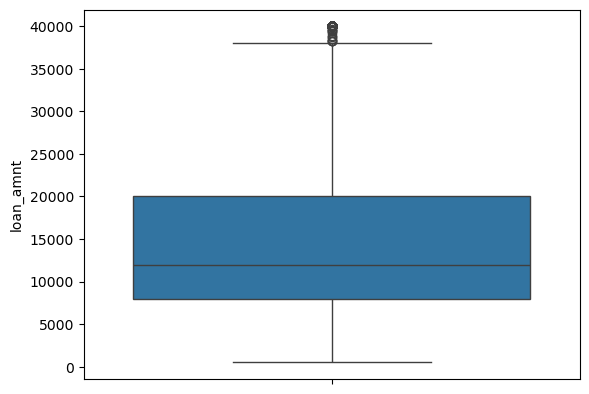

lower_outliers:  0
higher_outliers:  3144


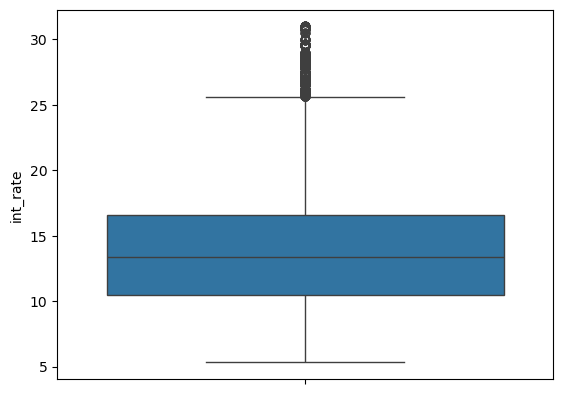

lower_outliers:  0
higher_outliers:  11114


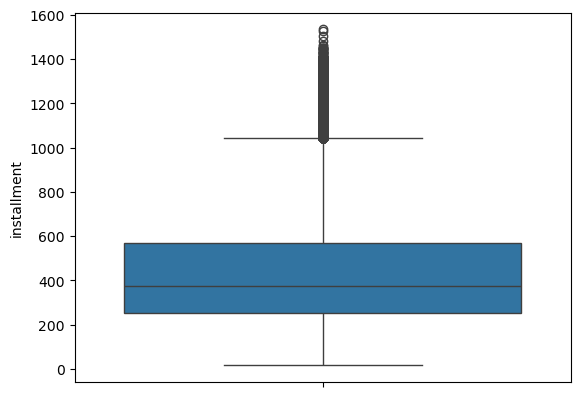

lower_outliers:  0
higher_outliers:  16649


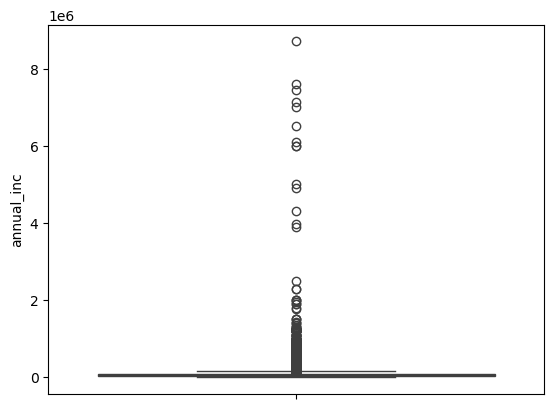

lower_outliers:  0
higher_outliers:  275


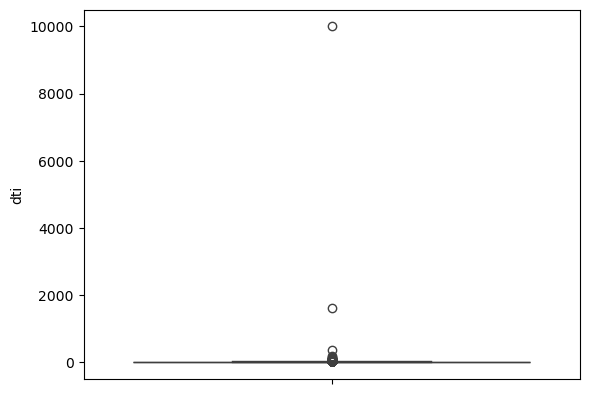

lower_outliers:  0
higher_outliers:  10297


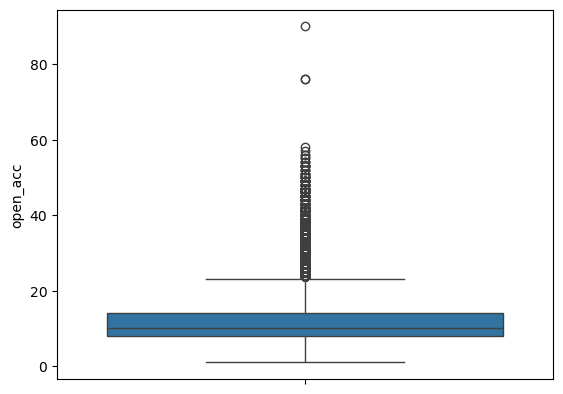

lower_outliers:  0
higher_outliers:  57730


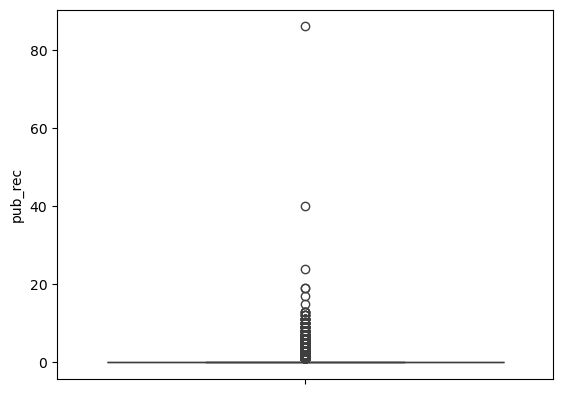

lower_outliers:  0
higher_outliers:  21205


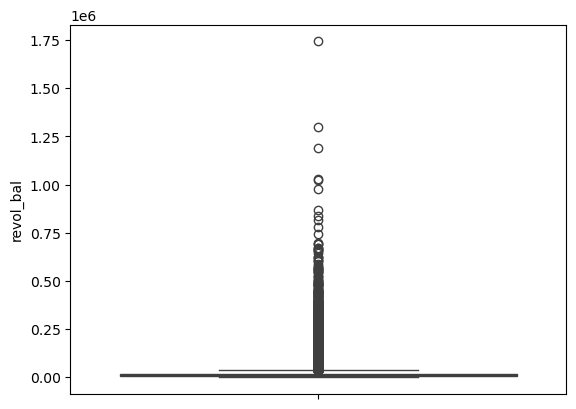

lower_outliers:  0
higher_outliers:  12


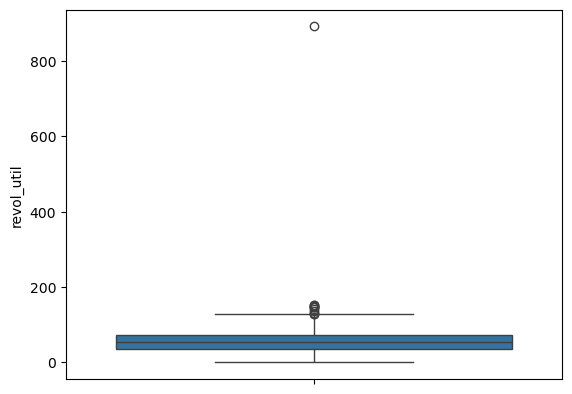

lower_outliers:  0
higher_outliers:  8491


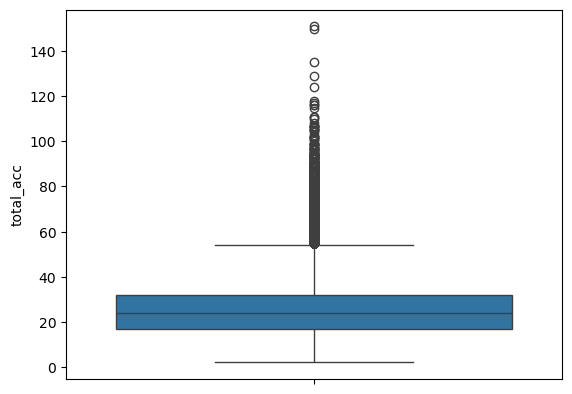

lower_outliers:  0
higher_outliers:  6837


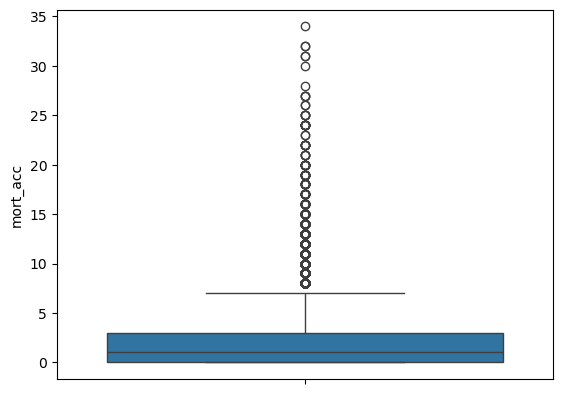

lower_outliers:  0
higher_outliers:  45111


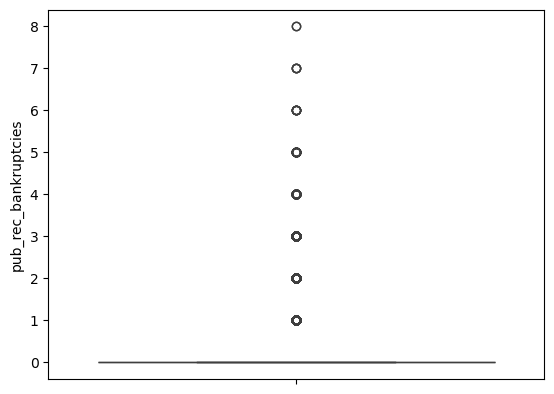

In [53]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    lower_outliers, higher_outliers = outlier_detection(df[col])
    print("lower_outliers: ", len(lower_outliers))
    print("higher_outliers: ", len(higher_outliers))
    sns.boxplot(df[col])
    plt.show()

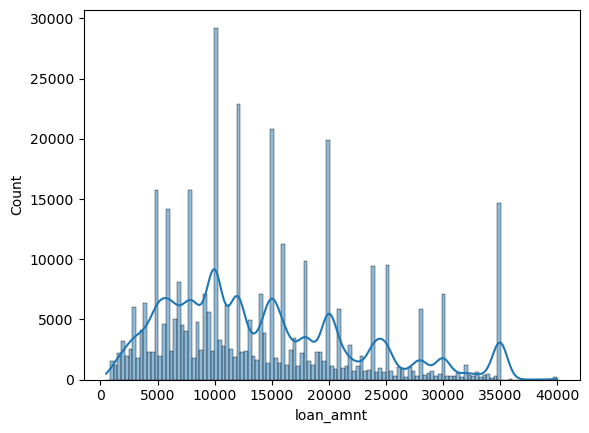

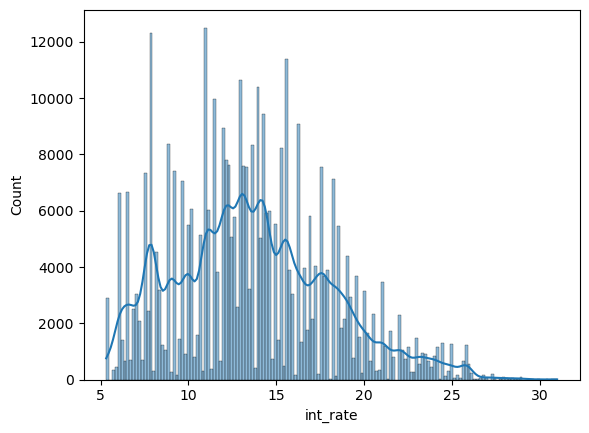

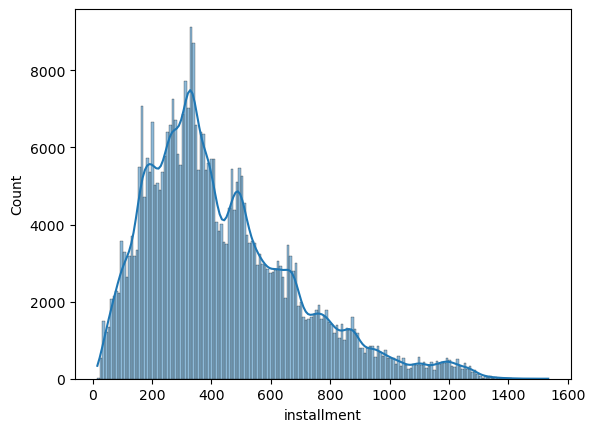

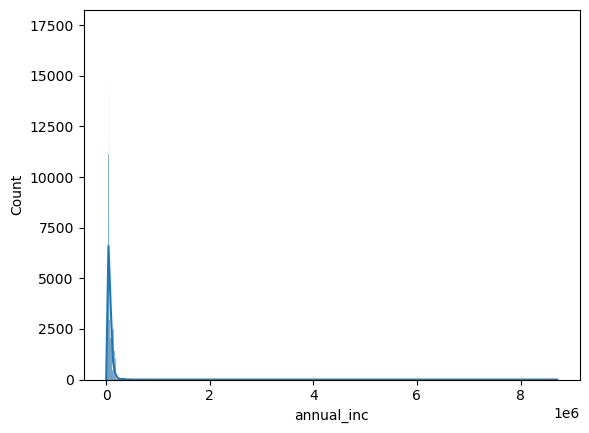

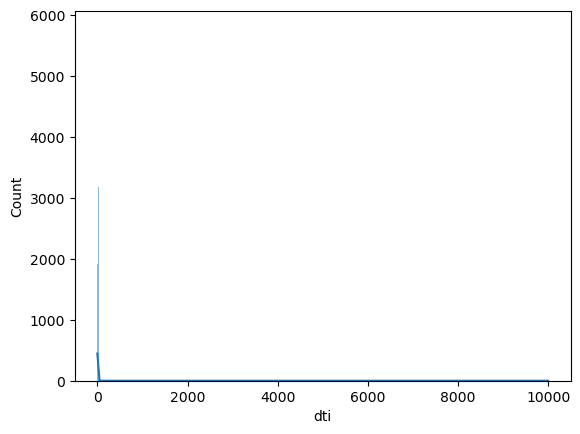

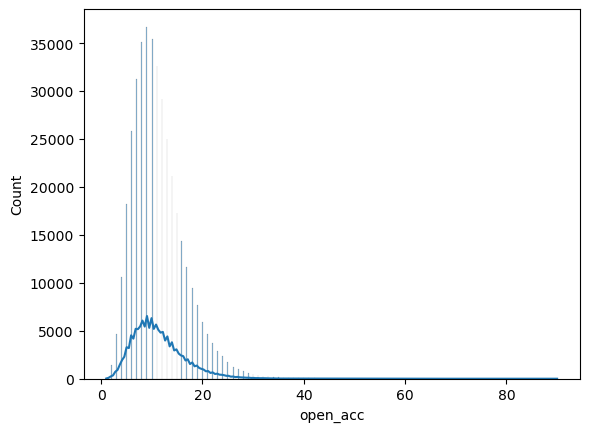

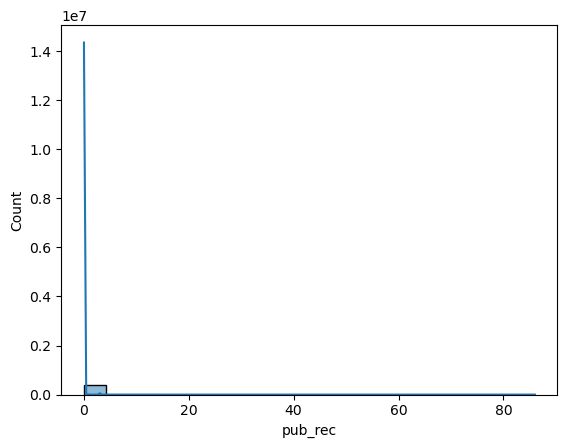

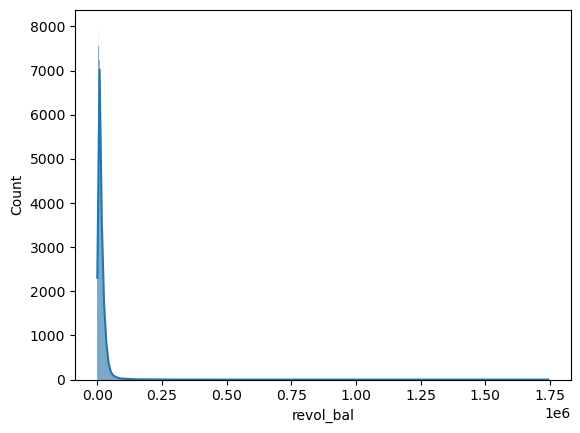

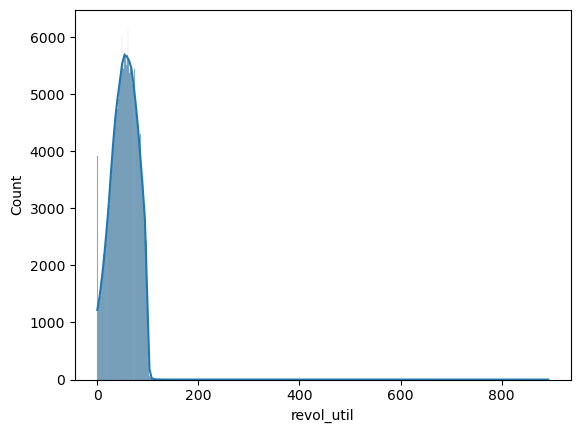

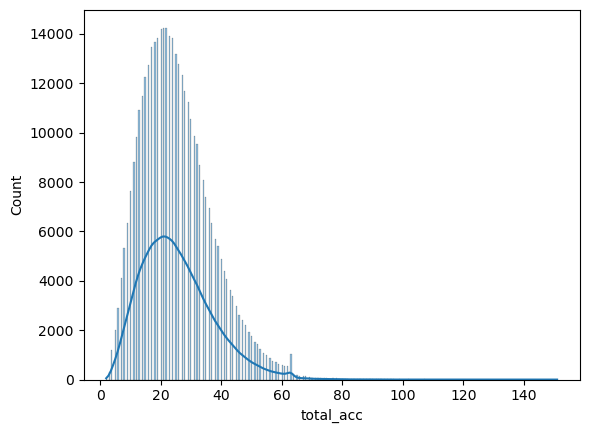

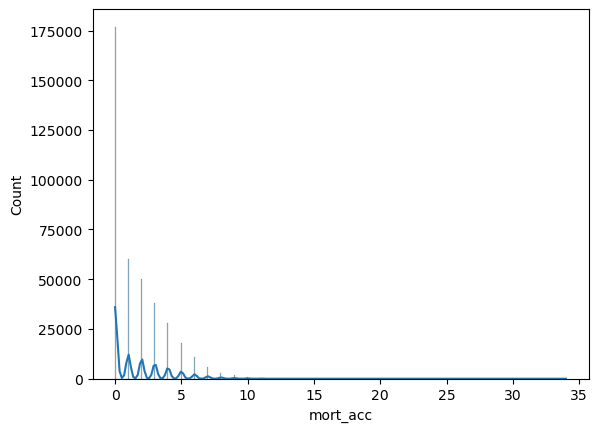

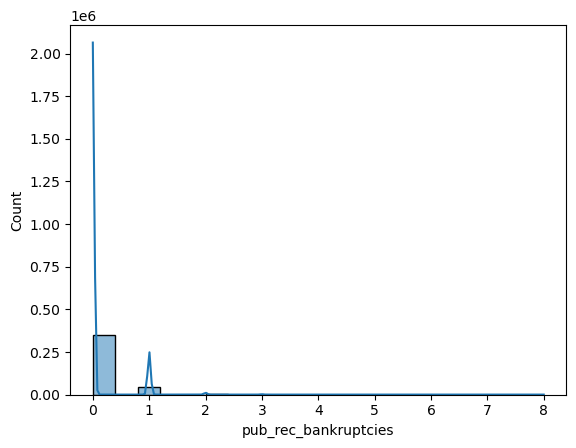

In [55]:
# Exploratory data analysis
for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

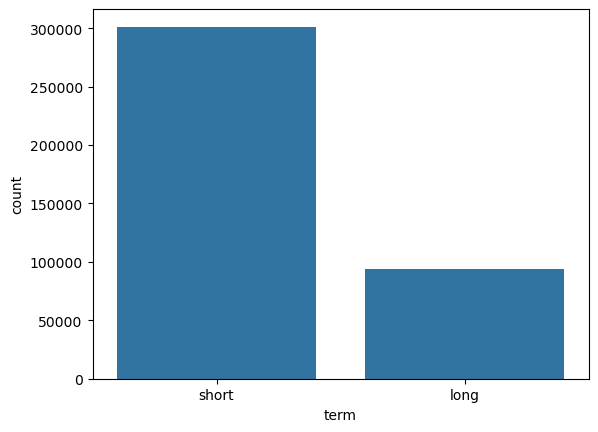

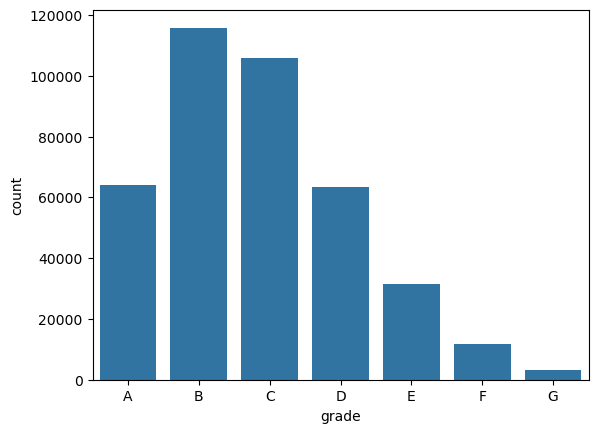

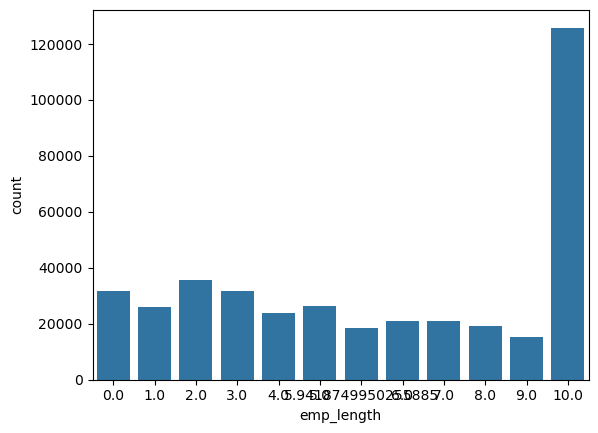

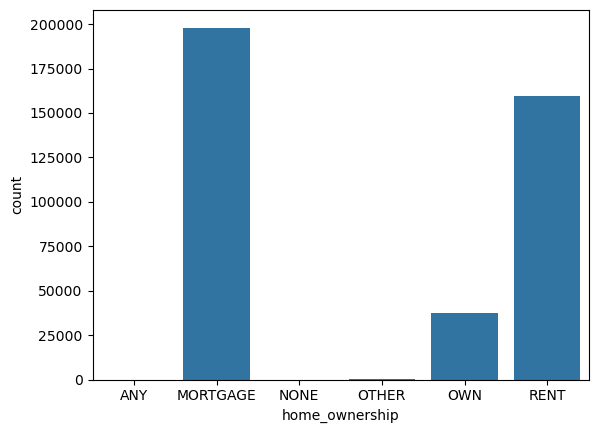

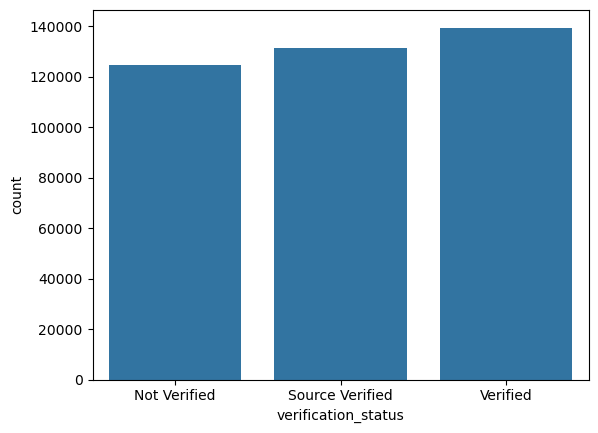

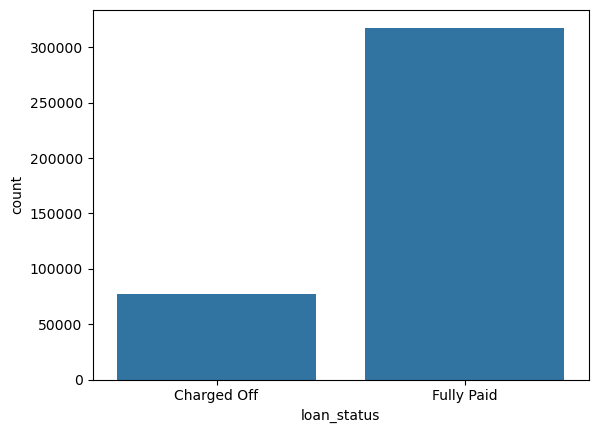

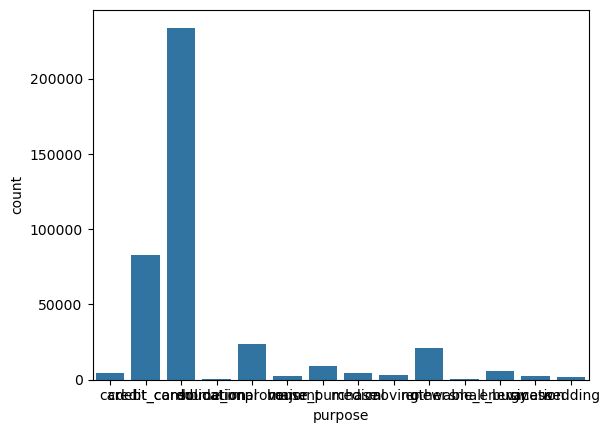

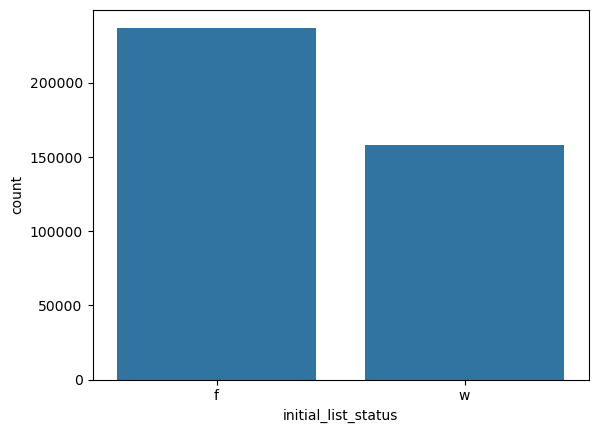

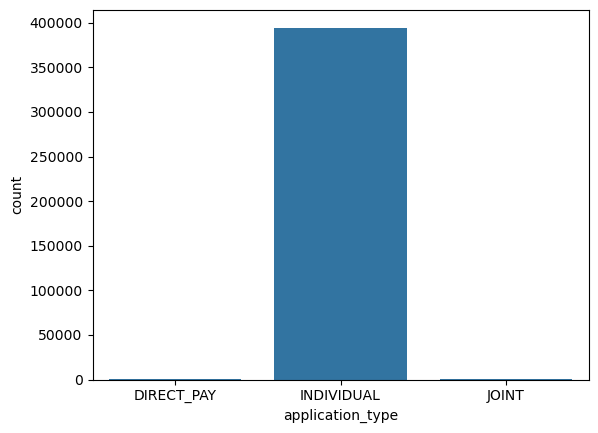

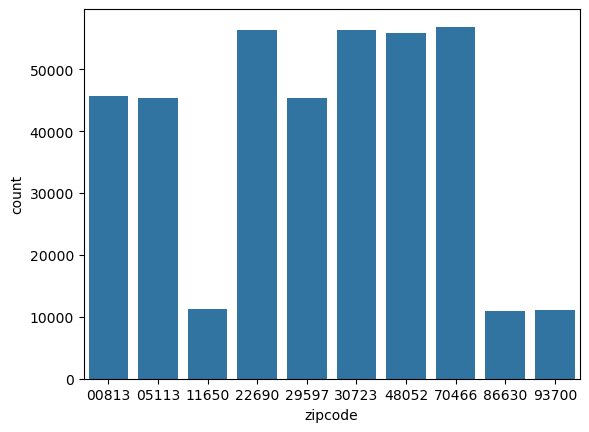

In [57]:
# Categorical variables
categorical_cols = df.select_dtypes(include='category').columns
for col in categorical_cols:
    sns.countplot(data=df, x=col)
    plt.show()

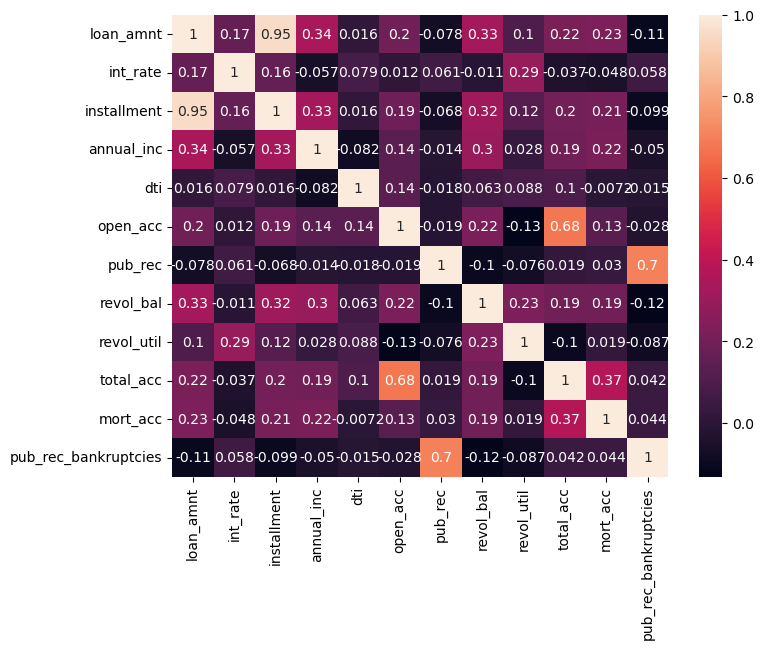

In [63]:
# Multivariate
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, ax=ax)
plt.show()

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395219 entries, 0 to 396029
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             395219 non-null  float64       
 1   term                  395219 non-null  category      
 2   int_rate              395219 non-null  float64       
 3   installment           395219 non-null  float64       
 4   grade                 395219 non-null  category      
 5   emp_length            395219 non-null  category      
 6   home_ownership        395219 non-null  category      
 7   annual_inc            395219 non-null  float64       
 8   verification_status   395219 non-null  category      
 9   issue_d               395219 non-null  datetime64[ns]
 10  loan_status           395219 non-null  category      
 11  purpose               395219 non-null  category      
 12  dti                   395219 non-null  float64       
 13  earl

In [69]:
df.drop(columns=['initial_list_status', 
                 'emp_length', 'issue_d', 'earliest_cr_line'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 395219 entries, 0 to 396029
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   loan_amnt             395219 non-null  float64 
 1   term                  395219 non-null  category
 2   int_rate              395219 non-null  float64 
 3   installment           395219 non-null  float64 
 4   grade                 395219 non-null  category
 5   home_ownership        395219 non-null  category
 6   annual_inc            395219 non-null  float64 
 7   verification_status   395219 non-null  category
 8   loan_status           395219 non-null  category
 9   purpose               395219 non-null  category
 10  dti                   395219 non-null  float64 
 11  open_acc              395219 non-null  float64 
 12  pub_rec               395219 non-null  float64 
 13  revol_bal             395219 non-null  float64 
 14  revol_util            395219 non-null  fl

In [73]:
# Multicollinearity
df_2 = df.drop(columns=['loan_status'])
df_2 = df_2.drop(columns=df_2.select_dtypes(include='category').columns)
df_2 = sm.add_constant(df_2)
vif = pd.DataFrame()
vif['Features'] = df_2.columns
vif['vif'] = [variance_inflation_factor(df_2.values, idx) for idx in range(len(df_2.columns))]
vif

,Features,vif
0,const,20.372308
1,loan_amnt,11.555798
2,int_rate,1.180089
3,installment,11.269496
4,annual_inc,1.239059
5,dti,1.048294
6,open_acc,2.045225
7,pub_rec,1.966914
8,revol_bal,1.316826
9,revol_util,1.243843


In [75]:
df.drop(columns=['installment'], inplace=True)

In [77]:
# Prepare features for running Logistic regression
df_3 = df.copy()
df_3.reset_index(drop=True, inplace=True)

In [79]:
X = df_3.drop(columns=['loan_status'])
y = df_3['loan_status']

In [81]:
y = y.replace({'Fully Paid': 0, 'Charged Off': 1}).astype(int)

/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_1911/1592694047.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'Fully Paid': 0, 'Charged Off': 1}).astype(int)
/var/folders/v3/pbt11cgx48b92xhbwckg3qsr0000gn/T/ipykernel_1911/1592694047.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y = y.replace({'Fully Paid': 0, 'Charged Off': 1}).astype(int)


In [85]:
X['term'] = X['term'].replace({'short':0, 'long':1}).astype('int8')

In [87]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395219 entries, 0 to 395218
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   loan_amnt             395219 non-null  float64 
 1   term                  395219 non-null  int8    
 2   int_rate              395219 non-null  float64 
 3   grade                 395219 non-null  category
 4   home_ownership        395219 non-null  category
 5   annual_inc            395219 non-null  float64 
 6   verification_status   395219 non-null  category
 7   purpose               395219 non-null  category
 8   dti                   395219 non-null  float64 
 9   open_acc              395219 non-null  float64 
 10  pub_rec               395219 non-null  float64 
 11  revol_bal             395219 non-null  float64 
 12  revol_util            395219 non-null  float64 
 13  total_acc             395219 non-null  float64 
 14  application_type      395219 non-nul

In [91]:
categorical_cols = X.select_dtypes(include='category').columns
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols))
X = pd.concat([X, encoded_df], axis=1)
X.drop(columns=categorical_cols, inplace=True)
X.head()

,loan_amnt,term,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,zipcode_00813,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
0,10000.0,0,11.44,117000.0,26.24,16.0,0.0,36369.0,41.8,25.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8000.0,0,11.99,65000.0,22.05,17.0,0.0,20131.0,53.3,27.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,15600.0,0,10.49,43057.0,12.79,13.0,0.0,11987.0,92.2,26.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7200.0,0,6.49,54000.0,2.60,6.0,0.0,5472.0,21.5,13.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,24375.0,1,17.27,55000.0,33.95,13.0,0.0,24584.0,69.8,43.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [99]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((316175, 55), (79044, 55), (316175,), (79044,))

In [101]:
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X_train)
X_train = pd.DataFrame(min_max_scaler.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(min_max_scaler.transform(X_test), columns=X_test.columns)

In [105]:
X_train.head()

,loan_amnt,term,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,zipcode_00813,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
0,0.236155,0.0,0.188157,0.008844,0.002009,0.134831,0.000000,0.006863,0.062311,0.181208,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.287078,0.0,0.149981,0.010796,0.001413,0.134831,0.011628,0.005299,0.032612,0.201342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.694462,1.0,0.303467,0.008040,0.001579,0.089888,0.000000,0.011445,0.081027,0.093960,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.439847,0.0,0.149981,0.004594,0.003399,0.213483,0.000000,0.007017,0.047630,0.194631,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.108848,0.0,0.301130,0.005513,0.000329,0.078652,0.011628,0.002866,0.064328,0.214765,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [109]:
y_train.value_counts(normalize=True)

loan_status
0    0.804061
1    0.195939
Name: proportion, dtype: float64

In [111]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
y_train.value_counts(normalize=True)

loan_status
0    0.5
1    0.5
Name: proportion, dtype: float64

In [115]:
model = LogisticRegression(solver='lbfgs', max_iter=10)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [117]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80    254224
           1       0.80      0.80      0.80    254224

    accuracy                           0.80    508448
   macro avg       0.80      0.80      0.80    508448
weighted avg       0.80      0.80      0.80    508448



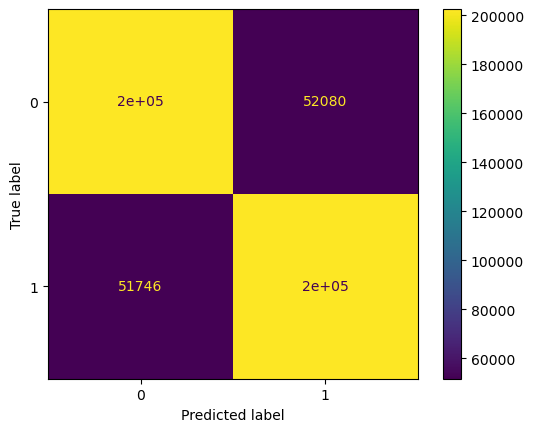

In [119]:
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

In [121]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86     63472
           1       0.49      0.79      0.61     15572

    accuracy                           0.80     79044
   macro avg       0.71      0.80      0.73     79044
weighted avg       0.85      0.80      0.81     79044



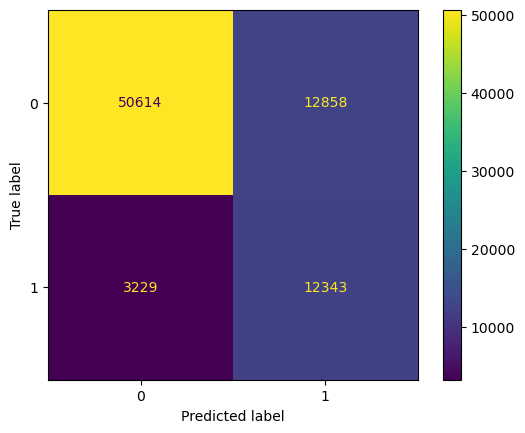

In [123]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

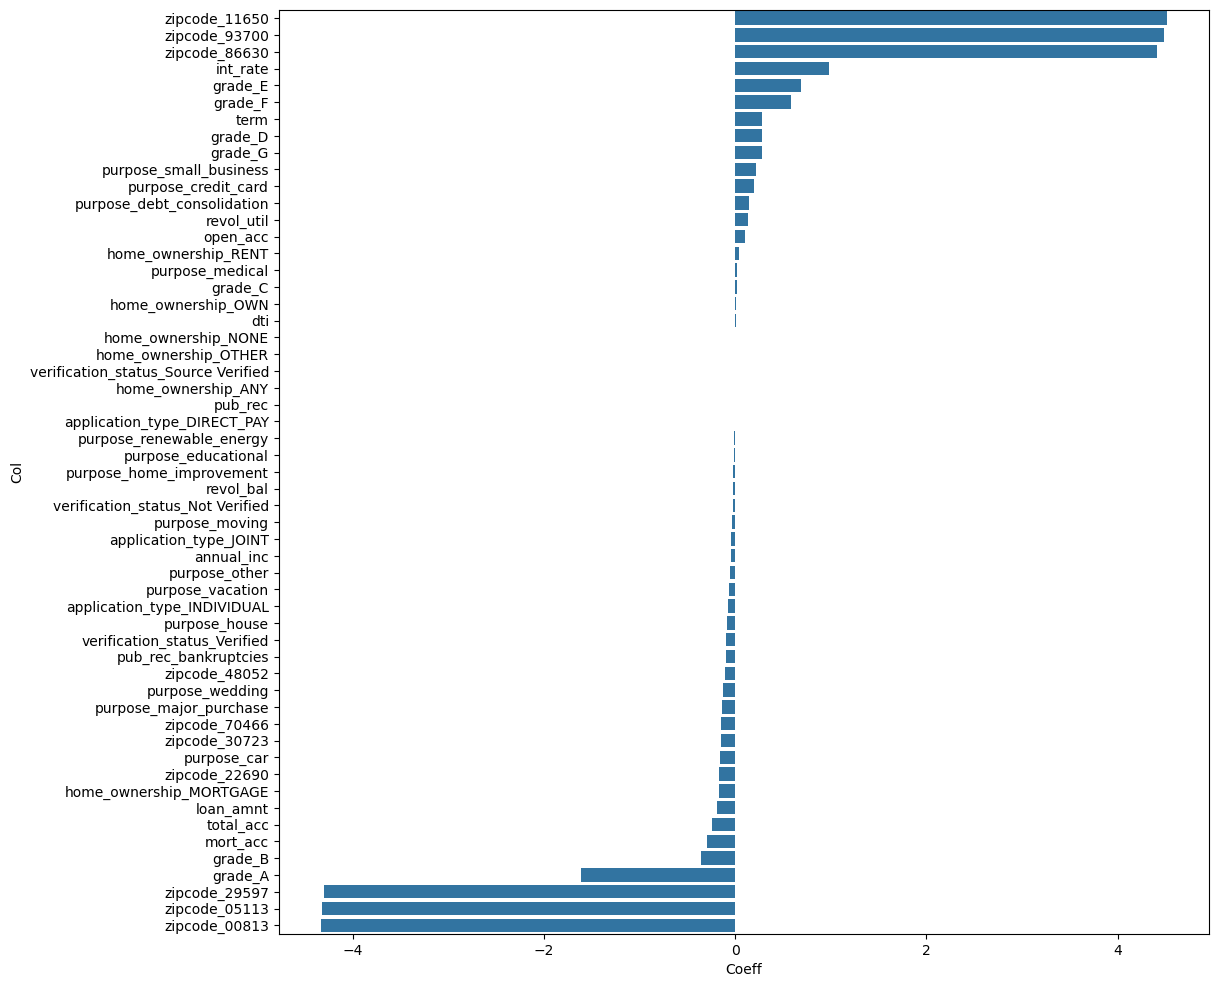

In [133]:
imp_features = pd.DataFrame({'Col': X_train.columns, 'Coeff': model.coef_[0]}).round(2).sort_values('Coeff', ascending=False)
plt.figure(figsize=(12,12))
sns.barplot(data=imp_features, y='Col', x='Coeff')
plt.show()

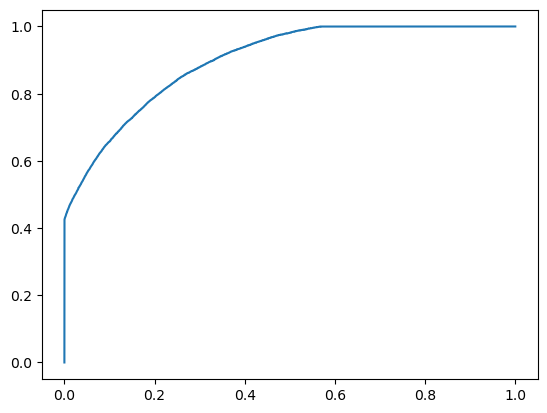

In [137]:
# ROC and AUC
probs = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.show()